In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import math
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

<div style="background:#fafafa; padding:20px; border-radius:10px;
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Explicit Finite Difference Scheme</b>

<p>
To introduce finite difference methods for parabolic PDEs, we begin with the
prototype diffusion equation
</p>

$$
u_t = \alpha\,u_{xx}, \qquad x \in (0,L), \ t > 0,
$$

<p>
subject to an initial condition \(u(x,0) = u_0(x)\) and boundary conditions
(e.g., Dirichlet).  
We discretize space using a uniform grid
</p>

$$
x_j = j\,\Delta x, \qquad j = 0,1,\dots,N,
$$

<p>
and time using steps
</p>

$$
t^n = n\,\Delta t, \qquad n = 0,1,\dots,M.
$$

<p>
Approximating the derivatives with forward Euler in time and centered differences
in space gives the <b>explicit scheme</b>
</p>

$$
u_j^{n+1}
=
u_j^n
+
\lambda\bigl(u_{j+1}^n - 2u_j^n + u_{j-1}^n\bigr),
\qquad
\lambda = \frac{\alpha\,\Delta t}{\Delta x^2}.
$$

<p>
This update uses only values from the previous time level, making the method
simple and computationally inexpensive.  
However, it is <b>conditionally stable</b>.  
A classical von Neumann analysis shows that stability requires
</p>

$$
\lambda \le \frac{1}{2},
\qquad\text{(CFL condition)}.
$$

<p>
If the time step violates this condition, the numerical solution develops
oscillations and eventually blows up.  
This sensitivity to the ratio \(\Delta t / \Delta x^2\) makes the explicit
scheme an ideal setting to visualize stability phenomena and the role of the CFL
condition.
</p>

</div>

In [7]:
class ExplicitHeat1D:
    def __init__(self, L=1.0, Nx=100, T=0.1, Nt=100, alpha=1.0):
        self.L = L
        self.Nx = Nx
        self.T = T
        self.Nt = Nt
        self.alpha = alpha

        self.dx = L / Nx
        self.dt = T / Nt
        self.lambda_cfl = alpha * self.dt / self.dx**2

        self.x = [j * self.dx for j in range(Nx + 1)]
        self.t = [n * self.dt for n in range(Nt + 1)]

        self.U = None

    def initial_condition(self, x):
        # Gaussian bump
        return math.exp(-100 * (x - 0.5*self.L)**2)

    def apply_boundary(self, u, t):
        u[0] = 0.0
        u[-1] = 0.0
        return u

    def solve(self):
        Nx, Nt = self.Nx, self.Nt
        lam = self.lambda_cfl

        U = [[0.0]*(Nx+1) for _ in range(Nt+1)]
 
        for j in range(Nx+1):
            U[0][j] = self.initial_condition(self.x[j])
        U[0] = self.apply_boundary(U[0], self.t[0])

        for n in range(Nt):
            u = U[n]
            u_new = u.copy()

            for j in range(1, Nx):
                u_new[j] = u[j] + lam * (u[j+1] - 2*u[j] + u[j-1])

            u_new = self.apply_boundary(u_new, self.t[n+1])
            U[n+1] = u_new

        self.U = U
        return U

    def plot(self, times=[0.0, None]):
        if self.U is None:
            raise RuntimeError("Call solve() before plot().")

        plt.figure(figsize=(7,4))

        for tau in times:
            if tau is None:
                idx = -1
            else:
                idx = min(range(len(self.t)), key=lambda i: abs(self.t[i] - tau))

            plt.plot(self.x, self.U[idx], label=f"t={self.t[idx]:.4f}")

        plt.title(f"Explicit Heat — λ = {self.lambda_cfl:.3f}")
        plt.xlabel("x")
        plt.ylabel("u(x,t)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

lambda = 0.5


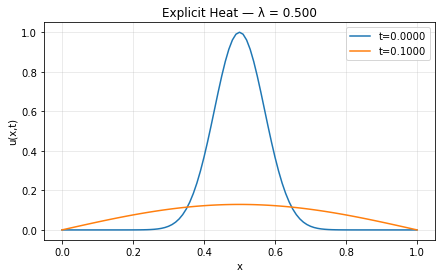

In [8]:
solver = ExplicitHeat1D(L=1.0, Nx=100, T=0.1, Nt=2000, alpha=1.0)
print("lambda =", solver.lambda_cfl)

U = solver.solve()
solver.plot(times=[0.0, solver.T])

lambda = 20.0


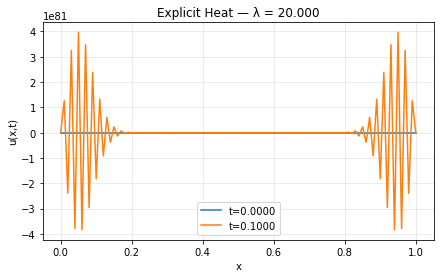

In [9]:
solver = ExplicitHeat1D(L=1.0, Nx=100, T=0.1, Nt=50, alpha=1.0)
print("lambda =", solver.lambda_cfl)

U = solver.solve()
solver.plot(times=[0.0, solver.T])

0.5


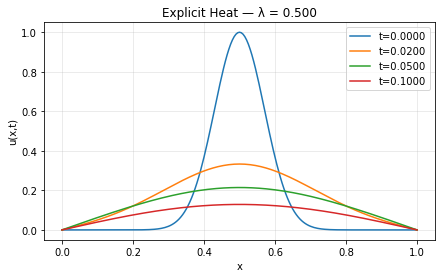

In [10]:
solver = ExplicitHeat1D(Nx=200, Nt=8000) 
print(solver.lambda_cfl)
solver.solve()
solver.plot(times=[0.0, 0.02, 0.05, 0.1])

In [11]:
def exact_solution(x, t):
    denom = 1 + 400*t
    return (1 / math.sqrt(denom)) * math.exp(-100*(x-0.5)**2 / denom)

solver = ExplicitHeat1D(Nx=200, Nt=8000)
solver.solve()

idx = -1
t_final = solver.t[idx]

errors = []
for j, xj in enumerate(solver.x):
    u_exact = exact_solution(xj, t_final)
    u_num = solver.U[idx][j]
    errors.append(abs(u_exact - u_num))

print("max error:", max(errors))

max error: 0.08487784863869177


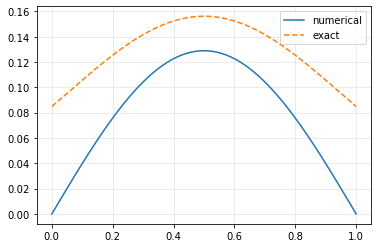

In [12]:
idx = -1
t_final = solver.t[idx]

u_exact = [exact_solution(xj, t_final) for xj in solver.x]
u_num = solver.U[idx]

plt.plot(solver.x, u_num, label="numerical")
plt.plot(solver.x, u_exact, label="exact", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="background:#fafafa; padding:20px; border-radius:10px;
            border:1px solid #ddd; font-size:110%;">

<p>
It is important to note that the “exact” solution used in this comparison corresponds to the heat equation posed on the entire real line, with no boundaries.  
Our numerical solution, however, is computed on the finite interval \([0,1]\) with Dirichlet boundary conditions \(u(0,t)=u(1,t)=0\).  
These boundary conditions force the solution to vanish at the endpoints and therefore distort the evolution compared to the unbounded case.  
A visible difference between the two solutions is expected.
</p>

</div>

<div style="background:#fafafa; padding:20px; border-radius:10px;
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Implicit Finite Difference Scheme</b>

<p>
The explicit method provides a simple time marching procedure for the heat
equation, but its stability is restricted by the CFL condition
\(\lambda \le 1/2\).  
To remove this limitation, we now consider an <b>implicit</b> time discretization.
Starting again from the diffusion equation
</p>

$$
u_t = \alpha\,u_{xx}, \qquad x \in (0,L), \ t > 0,
$$

<p>
we keep the same spatial grid \(x_j = j\,\Delta x\) and time grid
\(t^n = n\,\Delta t\).  
The key difference is that we approximate the time derivative using a backward
Euler step:
</p>

$$
\frac{u_j^{n+1} - u_j^n}{\Delta t}
=
\alpha\,\frac{u_{j+1}^{n+1} - 2u_j^{n+1} + u_{j-1}^{n+1}}{\Delta x^2}.
$$

<p>
Rearranging terms yields the <b>implicit scheme</b>
</p>

$$
-\,\lambda\,u_{j-1}^{n+1}
+
(1 + 2\lambda)\,u_j^{n+1}
-
\lambda\,u_{j+1}^{n+1}
=
u_j^n,
\qquad
\lambda = \frac{\alpha\,\Delta t}{\Delta x^2}.
$$

<p>
Unlike the explicit update, this formula couples all interior points at the new
time level \(n+1\).  
At each step we must therefore solve a tridiagonal linear system of the form
</p>

$$
A\,u^{n+1} = u^n,
$$

<p>
where \(A\) is a fixed tridiagonal matrix determined by \(\lambda\).  
This additional cost is compensated by a major advantage:  
<b>the implicit method is unconditionally stable</b>.  
No matter how large \(\Delta t\) is, the numerical solution remains stable.
</p>

<p>
This makes the implicit scheme particularly attractive for stiff problems or
situations where large time steps are desirable.
</p>

</div>

In [13]:
class ImplicitHeat1D:
    def __init__(self, L=1.0, Nx=100, T=0.1, Nt=100, alpha=1.0):
        self.L = L
        self.Nx = Nx
        self.T = T
        self.Nt = Nt
        self.alpha = alpha

        self.dx = L / Nx
        self.dt = T / Nt
        self.lambda_cfl = alpha * self.dt / self.dx**2

        self.x = [j * self.dx for j in range(Nx + 1)]
        self.t = [n * self.dt for n in range(Nt + 1)]

        self.U = None

    def initial_condition(self, x):
        return math.exp(-100 * (x - 0.5*self.L)**2)

    def apply_boundary(self, u, t):
        u[0] = 0.0
        u[-1] = 0.0
        return u

   
    def solve_tridiagonal(self, a, b, c, d):
        n = len(d)
        c_star = [0.0] * n
        d_star = [0.0] * n

        c_star[0] = c[0] / b[0]
        d_star[0] = d[0] / b[0]

        for i in range(1, n):
            denom = b[i] - a[i] * c_star[i-1]
            c_star[i] = c[i] / denom if i < n-1 else 0.0
            d_star[i] = (d[i] - a[i] * d_star[i-1]) / denom

        x = [0.0] * n
        x[-1] = d_star[-1]
        for i in range(n-2, -1, -1):
            x[i] = d_star[i] - c_star[i] * x[i+1]

        return x

    def solve(self):
        Nx, Nt = self.Nx, self.Nt
        lam = self.lambda_cfl

        U = [[0.0]*(Nx+1) for _ in range(Nt+1)]

        for j in range(Nx+1):
            U[0][j] = self.initial_condition(self.x[j])
        U[0] = self.apply_boundary(U[0], self.t[0])

        a = [-lam] * (Nx-1)
        b = [1 + 2*lam] * (Nx-1)
        c = [-lam] * (Nx-1)

        for n in range(Nt):
            rhs = U[n][1:-1] 
            u_new_inner = self.solve_tridiagonal(a, b, c, rhs)

            u_new = [0.0] + u_new_inner + [0.0]
            u_new = self.apply_boundary(u_new, self.t[n+1])

            U[n+1] = u_new

        self.U = U
        return U

    def plot(self, times=[0.0, None]):
        if self.U is None:
            raise RuntimeError("Call solve() before plot().")

        plt.figure(figsize=(7,4))

        for tau in times:
            if tau is None:
                idx = -1
            else:
                idx = min(range(len(self.t)), key=lambda i: abs(self.t[i] - tau))

            plt.plot(self.x, self.U[idx], label=f"t={self.t[idx]:.4f}")

        plt.title(f"Implicit Heat — λ = {self.lambda_cfl:.3f}")
        plt.xlabel("x")
        plt.ylabel("u(x,t)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

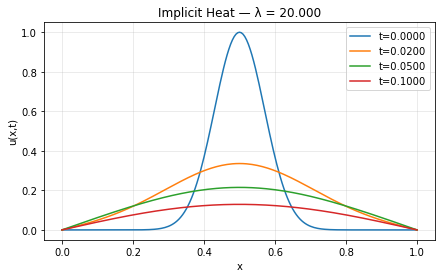

In [14]:
solver = ImplicitHeat1D(Nx=200, Nt=200)
solver.solve()
solver.plot(times=[0.0, 0.02, 0.05, 0.1])

lambda = 200.0


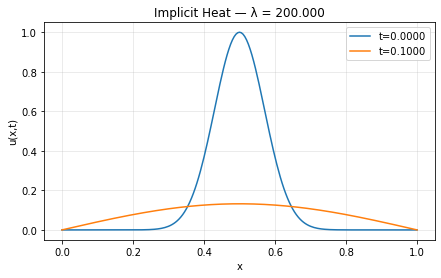

In [15]:
solver = ImplicitHeat1D(Nx=200, Nt=20)
print("lambda =", solver.lambda_cfl)

solver.solve()
solver.plot(times=[0.0, solver.T])

In [21]:
def exact_solution(x, t):
    denom = 1 + 400*t
    return (1 / math.sqrt(denom)) * math.exp(-100*(x-0.5)**2 / denom)

solver = ImplicitHeat1D(Nx=200, Nt=8000)
solver.solve()

idx = -1
t_final = solver.t[idx]

errors = []
for j, xj in enumerate(solver.x):
    u_exact = exact_solution(xj, t_final)
    u_num = solver.U[idx][j]
    errors.append(abs(u_exact - u_num))


print("max error:", max(errors))

max error: 0.08487784863869177


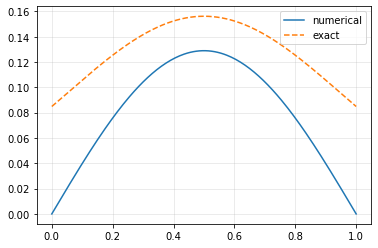

In [22]:
idx = -1
t_final = solver.t[idx]

u_exact = [exact_solution(xj, t_final) for xj in solver.x]
u_num = solver.U[idx]

plt.plot(solver.x, u_num, label="numerical")
plt.plot(solver.x, u_exact, label="exact", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
exp_solver = ExplicitHeat1D(Nx=200, Nt=8000)
exp_solver.solve()


imp_solver = ImplicitHeat1D(Nx=200, Nt=200)  
imp_solver.solve()


def exact_solution(x, t):
    denom = 1 + 400*t
    return (1 / math.sqrt(denom)) * math.exp(-100*(x-0.5)**2 / denom)

def max_error_vs_exact(solver):
    idx = -1
    t_final = solver.t[idx]
    return max(
        abs(exact_solution(x, t_final) - u)
        for x, u in zip(solver.x, solver.U[idx])
    )

print("explicit max error:", max_error_vs_exact(exp_solver))
print("implicit max error:", max_error_vs_exact(imp_solver))

explicit max error: 0.08487784863869177
implicit max error: 0.08487784863869177


In [24]:
diffs = [u_imp - u_exp for u_imp, u_exp in zip(imp_solver.U[-1], exp_solver.U[-1])]
print("max |implicit - explicit|:", max(abs(d) for d in diffs))

max |implicit - explicit|: 0.0003296216915522343


<div style="background:#fafafa; padding:20px; border-radius:10px;
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Crank–Nicolson Scheme</b>

<p>
The explicit and implicit Euler schemes represent two extremes: the explicit
method is simple but conditionally stable, while the implicit method is
unconditionally stable but introduces significant numerical damping.  
A natural compromise is the <b>Crank–Nicolson</b> method, which averages the
spatial discretization between time levels \(n\) and \(n+1\).
</p>

<p>
Starting from the diffusion equation
</p>

$$
u_t = \alpha\,u_{xx}, \qquad x \in (0,L), \ t > 0,
$$

<p>
we use the same spatial grid \(x_j = j\,\Delta x\) and time grid
\(t^n = n\,\Delta t\).  
The Crank–Nicolson discretization reads
</p>

$$
\frac{u_j^{n+1} - u_j^n}{\Delta t}
=
\alpha\,\frac{1}{2}
\left[
\frac{u_{j+1}^{n+1} - 2u_j^{n+1} + u_{j-1}^{n+1}}{\Delta x^2}
+
\frac{u_{j+1}^{n} - 2u_j^{n} + u_{j-1}^{n}}{\Delta x^2}
\right].
$$

<p>
Rearranging terms gives the <b>Crank–Nicolson update</b>
</p>

$$
-\frac{\lambda}{2}\,u_{j-1}^{n+1}
+
(1 + \lambda)\,u_j^{n+1}
-
\frac{\lambda}{2}\,u_{j+1}^{n+1}
=
\frac{\lambda}{2}\,u_{j-1}^{n}
+
(1 - \lambda)\,u_j^{n}
+
\frac{\lambda}{2}\,u_{j+1}^{n},
\qquad
\lambda = \frac{\alpha\,\Delta t}{\Delta x^2}.
$$

<p>
At each time step we must solve a tridiagonal linear system, as in the implicit
Euler method.  
However, Crank–Nicolson offers two major advantages:
</p>

<ul>
<li><b>Second-order accuracy in time</b>, thanks to the trapezoidal averaging.</li>
<li><b>Unconditional stability</b> without the excessive damping of backward Euler.</li>
</ul>

<p>
This makes Crank–Nicolson the preferred method in many applications, including
option pricing (Black–Scholes), where accuracy and stability are both essential.
In the next section, we implement the Crank–Nicolson scheme using the same
class-based structure as before.
</p>

</div>

In [25]:
class CrankNicolsonHeat1D:
    def __init__(self, L=1.0, Nx=100, T=0.1, Nt=100, alpha=1.0):
        self.L = L
        self.Nx = Nx
        self.T = T
        self.Nt = Nt
        self.alpha = alpha

        self.dx = L / Nx
        self.dt = T / Nt
        self.lambda_cfl = alpha * self.dt / self.dx**2

        self.x = [j * self.dx for j in range(Nx + 1)]
        self.t = [n * self.dt for n in range(Nt + 1)]

        self.U = None

    def initial_condition(self, x):
        return math.exp(-100 * (x - 0.5*self.L)**2)

    def apply_boundary(self, u, t):
        u[0] = 0.0
        u[-1] = 0.0
        return u

    def solve_tridiagonal(self, a, b, c, d):
        n = len(d)
        c_star = [0.0] * n
        d_star = [0.0] * n

        c_star[0] = c[0] / b[0]
        d_star[0] = d[0] / b[0]

        for i in range(1, n):
            denom = b[i] - a[i] * c_star[i-1]
            c_star[i] = c[i] / denom if i < n-1 else 0.0
            d_star[i] = (d[i] - a[i] * d_star[i-1]) / denom

        x = [0.0] * n
        x[-1] = d_star[-1]
        for i in range(n-2, -1, -1):
            x[i] = d_star[i] - c_star[i] * x[i+1]

        return x

    def solve(self):
        Nx, Nt = self.Nx, self.Nt
        lam = self.lambda_cfl

        U = [[0.0]*(Nx+1) for _ in range(Nt+1)]

        for j in range(Nx+1):
            U[0][j] = self.initial_condition(self.x[j])
        U[0] = self.apply_boundary(U[0], self.t[0])


        a = [-0.5*lam] * (Nx-1)
        b = [1.0 + lam] * (Nx-1)
        c = [-0.5*lam] * (Nx-1)

        for n in range(Nt):
            u_old = U[n]

            rhs = [0.0] * (Nx-1)
            for j in range(1, Nx):
                rhs[j-1] = (
                    0.5*lam * u_old[j-1]
                    + (1.0 - lam) * u_old[j]
                    + 0.5*lam * u_old[j+1]
                )

            u_new_inner = self.solve_tridiagonal(a, b, c, rhs)

            u_new = [0.0] + u_new_inner + [0.0]
            u_new = self.apply_boundary(u_new, self.t[n+1])

            U[n+1] = u_new

        self.U = U
        return U

    def plot(self, times=[0.0, None]):
        if self.U is None:
            raise RuntimeError("Call solve() before plot().")

        plt.figure(figsize=(7,4))

        for tau in times:
            if tau is None:
                idx = -1
            else:
                idx = min(range(len(self.t)), key=lambda i: abs(self.t[i] - tau))

            plt.plot(self.x, self.U[idx], label=f"t={self.t[idx]:.4f}")

        plt.title(f"Crank–Nicolson Heat — λ = {self.lambda_cfl:.3f}")
        plt.xlabel("x")
        plt.ylabel("u(x,t)")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

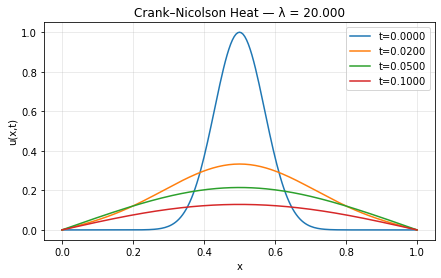

In [26]:
solver = CrankNicolsonHeat1D(Nx=200, Nt=200)
solver.solve()
solver.plot(times=[0.0, 0.02, 0.05, 0.1])

lambda = 200.0


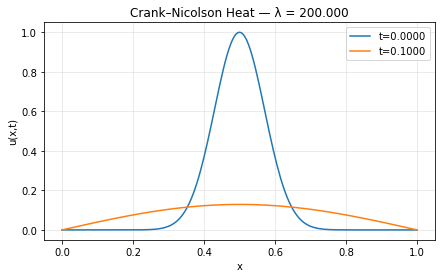

In [27]:
solver = CrankNicolsonHeat1D(Nx=200, Nt=20) 
print("lambda =", solver.lambda_cfl)

solver.solve()
solver.plot(times=[0.0, solver.T])

In [29]:
def exact_solution(x, t):
    denom = 1 + 400*t
    return (1 / math.sqrt(denom)) * math.exp(-100*(x-0.5)**2 / denom)

solver = CrankNicolsonHeat1D(Nx=200, Nt=8000)
solver.solve()

idx = -1
t_final = solver.t[idx]

errors = []
for xj, uj in zip(solver.x, solver.U[idx]):
    errors.append(abs(exact_solution(xj, t_final) - uj))

print("CN max error:", max(errors))

CN max error: 0.08487784863869177


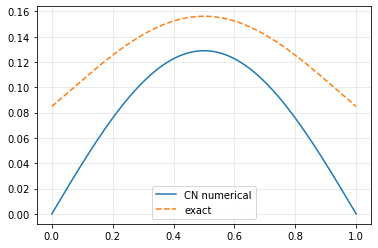

In [30]:
u_exact = [exact_solution(xj, t_final) for xj in solver.x]
u_num   = solver.U[idx]

plt.plot(solver.x, u_num, label="CN numerical")
plt.plot(solver.x, u_exact, label="exact", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()